# 06. Hydro and climate as one model

Notebooks 01 to 05 fit the two disaster classes in parallel. Every parameter carries a class index with its own prior, and nothing ties a country-year's hydro count to its climate count beyond the covariates they share. This notebook starts the joint series from notebook 02 and asks the smallest joint question there is: after the covariates, does a country that records more of one class than expected record more of the other?

The model is notebook 02 with one parameter added, the correlation between a country's two intercepts. A second model adds a correlated frailty at the row level as well, to check whether the shared movement is confined to the country level. The presentation is shorter than notebooks 01 to 05, since the covariates, the checks, and the fit machinery are the same. Sections: the data, the model, its diagnostics, what the posterior predicts, the correlation against its prior, both levels at once, the comparison with notebooks 01 and 02, and what was learned.

In [1]:
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import preliz as pz
import pymc as pm
import xarray as xr

from arviz_plots import plot_energy, plot_trace
from checks import plot_country_counts, plot_coverage, plot_posterior_with_prior, summarize

from climate_risk.plotting import configure_plot_style
from climate_risk.replication_data import MODEL_FEATURES, create_replication_data
from climate_risk.sample import sample_or_load
from climate_risk.stats.scaling import standardize

configure_plot_style()

In [2]:
PROJECT_ROOT = next(p for p in Path.cwd().parents if (p / "pyproject.toml").exists())
CACHE_DIR = PROJECT_ROOT / "data"
FIT_DIR = Path("fits")

SEED = sum(map(ord, "climate_bayes"))

CLASSES = ["climate", "hydro"]
COUNTS = {"climate": "climatological_disasters", "hydro": "hydrological_disasters"}

# The paper's covariates with population logged, as in notebook 01.
FEATURES = [("ln_population" if name == "population" else name) for name in MODEL_FEATURES]

## The data

The panel of notebooks 01 and 02: a country-year enters when it carries every covariate, and a missing count is a recorded zero.

In [3]:
panel = (create_replication_data(CACHE_DIR)
         .to_pandas()
         .rename(columns={"ISO": "iso"})
         .assign(ln_population=lambda frame: np.log(frame["population"]))
         .dropna(subset=FEATURES)
         .reset_index(drop=True))

counts = panel[[COUNTS[name] for name in CLASSES]].fillna(0.0).astype(int)
counts.columns = CLASSES

_, scaled = standardize(panel, FEATURES)
SCALED_FEATURES = [f"{name}__standardized" for name in FEATURES]

codes = sorted(panel["iso"].unique())
country_idx = panel["iso"].map({code: position for position, code in enumerate(codes)}).to_numpy()

print(f"{len(panel)} country-years, {len(codes)} countries, "
      f"{panel['date'].dt.year.min()} to {panel['date'].dt.year.max()}")

7710 country-years, 199 countries, 1981 to 2023


## The model

Per class $c$, country $j$, and country-year $i$ in country $j$,

$$
\begin{aligned}
y_{ic} &\sim \operatorname{NegativeBinomial}(\mu_{ic},\ \alpha_c) \\
\log \mu_{ic} &= a_c + x_i^\top \beta_c + u_{jc} \\
u_j &\sim \operatorname{MvNormal}(0,\ \Sigma_u), \quad u_j \in \mathbb{R}^2
\end{aligned}
$$

Notebook 02 drew each country's two intercepts independently, $u_{jc} \sim \operatorname{Normal}(0, \tau_c)$. Here the pair is one draw from a bivariate normal, and the off-diagonal of $\Sigma_u$ is the correlation between a country's hydro and climate departures from the covariates over 43 years. The intercepts are written non-centered, as standard normals times the Cholesky factor of $\Sigma_u$. The negative binomial keeps the row-level overdispersion class-specific and independent across classes, as in 02.

$\Sigma_u$ carries an LKJ prior with concentration 2 on the correlation, which is flat-ish and puts a little mass away from the extremes, and `HalfNormal(1)` on the scales, which is 02's prior on $\tau_c$. The intercepts, slopes, and dispersions carry the priors of notebook 02. The zero inflation stays out, as notebook 01 found it empty.

In [4]:
coords = {
    "obs_idx": panel.index,
    "iso": codes,
    "disaster": CLASSES,
    "feature": FEATURES,
}

with pm.Model(coords=coords) as country_model:
    X = pm.Data("X", scaled[SCALED_FEATURES].to_numpy(), dims=["obs_idx", "feature"])
    country = pm.Data("country", country_idx, dims=["obs_idx"])

    intercept = pm.Normal("intercept", 0, 1, dims=["disaster"])
    beta = pm.Normal("beta", 0, 0.5, dims=["feature", "disaster"])
    alpha = pm.Gamma("alpha", alpha=2, beta=1, dims=["disaster"])

    country_chol, country_corr, country_scale = pm.LKJCholeskyCov("country_cov",
                                                                  n=len(CLASSES),
                                                                  eta=2,
                                                                  sd_dist=pm.HalfNormal.dist(1),
                                                                  compute_corr=True)
    pm.Deterministic("country_corr", country_corr[0, 1])
    pm.Deterministic("country_scale", country_scale, dims=["disaster"])
    country_offset = pm.Normal("country_offset", 0, 1, dims=["iso", "disaster"])
    country_effect = pm.Deterministic("country_effect", country_offset @ country_chol.T, dims=["iso", "disaster"])

    log_mu = intercept + X @ beta + country_effect[country]
    mu = pm.Deterministic("mu", pm.math.exp(log_mu), dims=["obs_idx", "disaster"])

    pm.NegativeBinomial("y", mu=mu, alpha=alpha, observed=counts.to_numpy(), dims=["obs_idx", "disaster"])

country_model

               X = Data(<shared>)
         country = Data(<shared>)
       intercept ~ Normal(0, 1)
            beta ~ Normal(0, 0.5)
           alpha ~ Gamma(2, <constant>)
     country_cov ~ _lkjcholeskycov(2, 2, HalfNormal(0, 1))
  country_offset ~ Normal(0, 1)
country_cov_corr = Deterministic(f(country_cov))
country_cov_stds = Deterministic(f(country_cov))
    country_corr = Deterministic(f(country_cov_corr))
   country_scale = Deterministic(f(country_cov_stds))
  country_effect = Deterministic(f(country_offset, country_cov))
              mu = Deterministic(f(country, country_effect, beta, X, intercept))
               y ~ NegativeBinomial(alpha, f(mu, alpha))

## The fit and its diagnostics

The draws land in `fits/`, which is gitignored, and `sample_or_load` reads them back without checking they match the data in memory. Pass `force_resample=True` after a change to the panel. The warmup draws are kept, and the traces of the two scales and the correlation follow the summary.

In [5]:
sample_kwargs = dict(chains=8,
                     cores=8,
                     tune=500,
                     draws=250,
                     discard_tuned_samples=False,
                     random_seed=SEED)

with country_model:
    idata = sample_or_load(fp=str(FIT_DIR / "joint_country_intercept.nc"), sample_kwargs=sample_kwargs)

PARAMETERS = ["intercept", "beta", "alpha", "country_scale", "country_corr"]
summarize(idata, PARAMETERS)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept[climate],-2.28,0.07,-2.39,-2.17,963.69,1214.15,1.01,0.00,0.00
intercept[hydro],-0.68,0.06,-0.77,-0.59,593.87,873.21,1.01,0.00,0.00
"beta[ln_population_density, climate]",-0.13,0.07,-0.24,-0.02,613.84,1021.95,1.02,0.00,0.00
"beta[ln_population_density, hydro]",0.16,0.06,0.07,0.25,688.74,871.72,1.01,0.00,0.00
"beta[ln_gdp_pc, climate]",-0.43,0.28,-0.88,0.00,257.50,407.42,1.03,0.02,0.01
"beta[ln_gdp_pc, hydro]",0.41,0.23,0.04,0.77,124.42,204.02,1.08,0.02,0.01
"beta[square_ln_gdp_pc, climate]",0.50,0.28,0.08,0.96,256.12,446.65,1.03,0.02,0.01
"beta[square_ln_gdp_pc, hydro]",-0.55,0.24,-0.93,-0.15,101.76,176.47,1.09,0.02,0.02
"beta[precip_deviation, climate]",-0.37,0.04,-0.43,-0.31,2521.65,1593.69,1.00,0.00,0.00
"beta[precip_deviation, hydro]",0.24,0.01,0.22,0.27,4146.31,1683.34,1.01,0.00,0.00


0 divergences; worst r_hat 1.090; smallest bulk ESS 102 (beta[square_ln_gdp_pc, hydro])


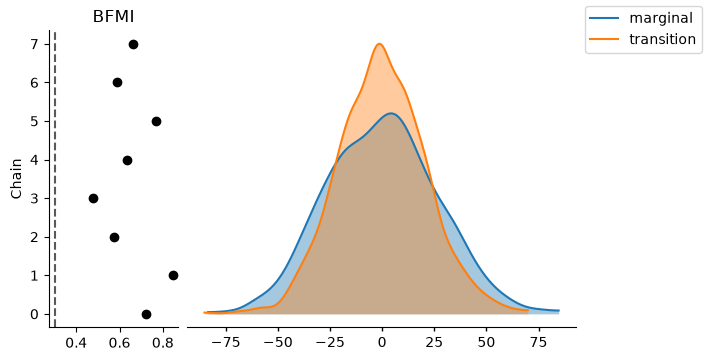

In [6]:
diagnostics = summarize(idata, [*PARAMETERS, "country_offset"])[["ess_bulk", "ess_tail", "r_hat"]]
divergences = int(idata.sample_stats["diverging"].sum())

print(f"{divergences} divergences; worst r_hat {diagnostics['r_hat'].max():.3f}; "
      f"smallest bulk ESS {diagnostics['ess_bulk'].min():.0f} ({diagnostics['ess_bulk'].idxmin()})")
plot_energy(idata, backend="matplotlib", figure_kwargs={"figsize": (7, 3.5)})
plt.show()

### Adaptation

The warmup traces of the two scales and the correlation, one line per chain.

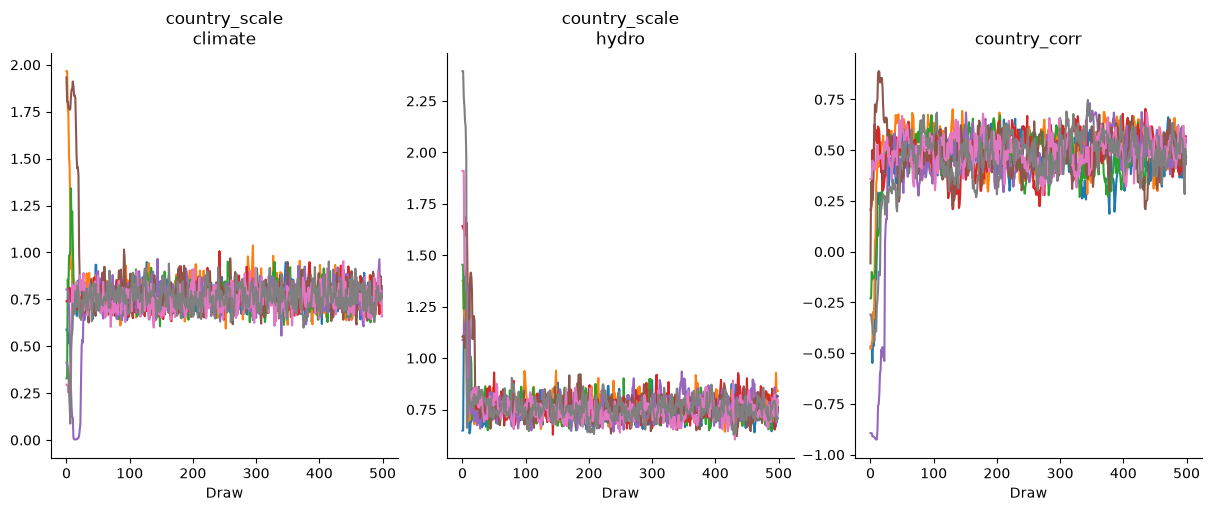

In [7]:
scales = idata.warmup_posterior.to_dataset()[["country_scale", "country_corr"]]
plot_trace(xr.DataTree.from_dict({"posterior": scales}),
           backend="matplotlib",
           figure_kwargs={"figsize": (12, 5)})
plt.show()

## What the posterior predicts

The interval coverage and the three countries, as in notebook 02. A country intercept has 43 observations behind it, so conditioning on it is the model's forecast for a known country and the standard posterior predictive is the one to check. The country totals are over-covered by construction, as in 02, since each country's intercepts sit on its totals.

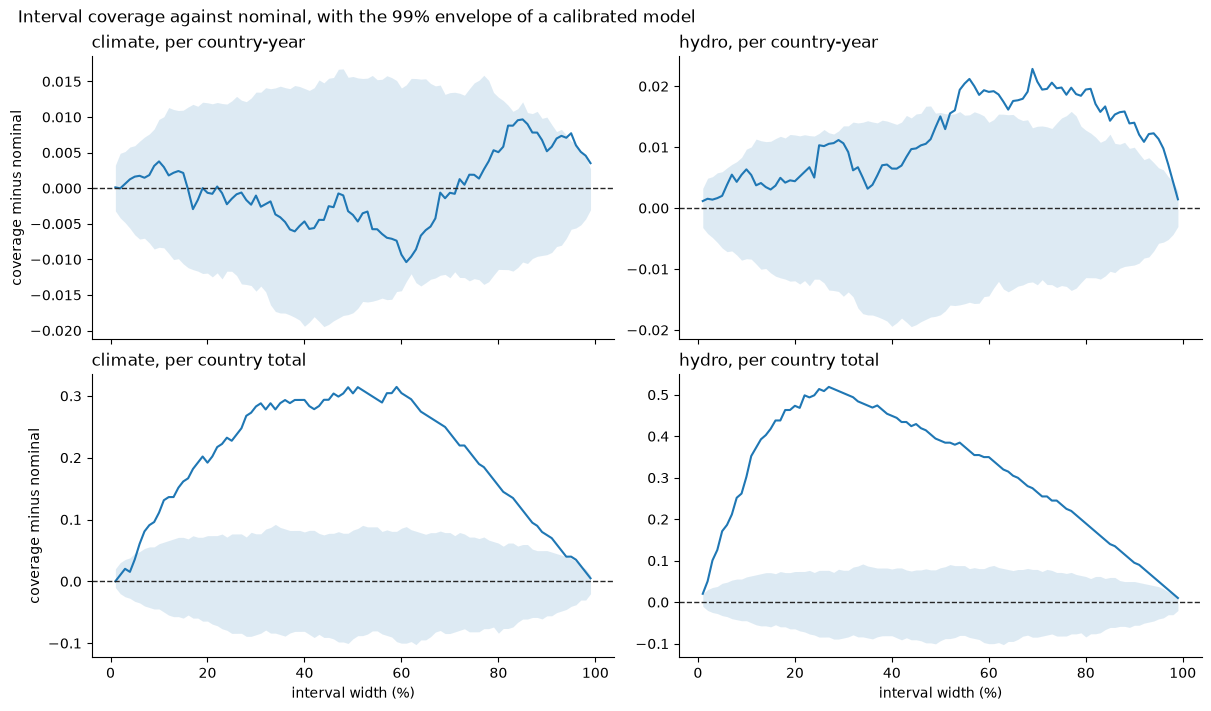

In [8]:
plot_coverage(idata, panel["iso"].to_numpy(), CLASSES)

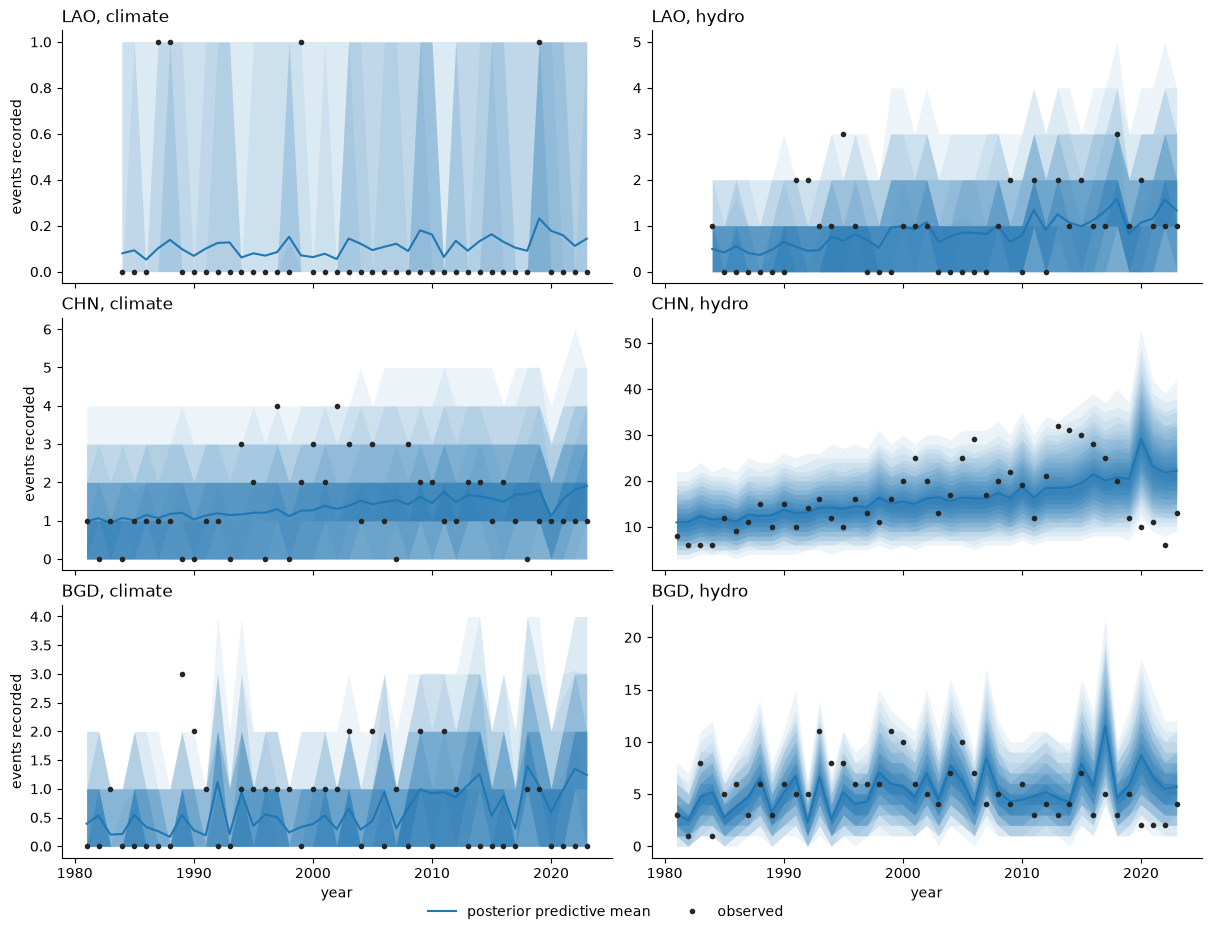

In [9]:
plot_country_counts(idata.posterior_predictive["y"], panel, counts, ["LAO", "CHN", "BGD"], CLASSES)

## The correlation against its prior

The posterior of the correlation, the two scales, and the dispersions over their priors. The LKJ prior on the correlation is drawn as the marginal it implies for a 2 by 2 matrix with concentration 2, which is `Beta(2, 2)` stretched to $[-1, 1]$. The scales are notebook 02's `tau`, and the point of showing them is that they did not move.

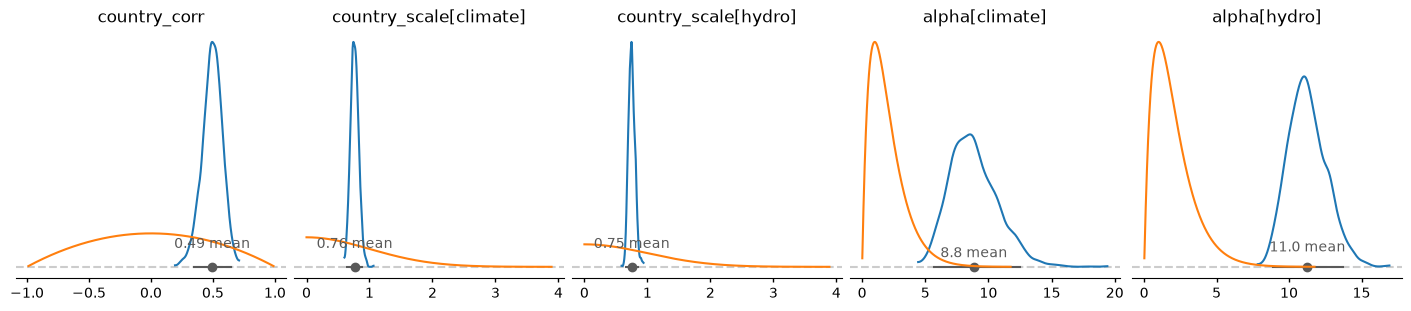

In [10]:
posterior = idata.posterior
of_interest = xr.Dataset({
    "country_corr": posterior["country_corr"],
    **{f"country_scale[{name}]": posterior["country_scale"].sel(disaster=name, drop=True) for name in CLASSES},
    **{f"alpha[{name}]": posterior["alpha"].sel(disaster=name, drop=True) for name in CLASSES},
})

priors = {
    "country_corr": pz.BetaScaled(alpha=2, beta=2, lower=-1, upper=1),
    **{f"country_scale[{name}]": pz.HalfNormal(1) for name in CLASSES},
    **{f"alpha[{name}]": pz.Gamma(alpha=2, beta=1) for name in CLASSES},
}

plot_posterior_with_prior(of_interest, priors, n_cols=5)
plt.show()

## Both levels at once

A correlation between country intercepts can only hold what persists across a country's 43 years. Whatever the two classes share within a single country-year, a hazard year or a reporting year, has nowhere to go in a negative binomial, whose frailties are independent across classes. The check is a model with a correlated frailty at both levels:

$$
\begin{aligned}
y_{ic} &\sim \operatorname{Poisson}(\mu_{ic}) \\
\log \mu_{ic} &= a_c + x_i^\top \beta_c + u_{jc} + \eta_{ic} \\
u_j &\sim \operatorname{MvNormal}(0,\ \Sigma_u), \qquad \eta_i \sim \operatorname{MvNormal}(0,\ \Sigma_\eta)
\end{aligned}
$$

The row-level lognormal frailty $\eta_i$ replaces the gamma frailty inside the negative binomial, with its own 2 by 2 covariance $\Sigma_\eta$. With 43 rows a country the two levels are separately identified: $u_j$ is what a country's rows share and $\eta_i$ is what is left in each row. If $\Sigma_u$'s correlation holds and $\Sigma_\eta$'s is near zero, the country level is the whole story. The row-level latent costs one parameter per observation, so this model's predictive checks reproduce the data and its LOO is unreliable, and it is a check on the first model and is not carried forward.

The fit runs 1,000 draws a chain in place of the usual 250, since a row-level correlation coupled to 7,710 latent pairs mixes slowly.

In [11]:
with pm.Model(coords=coords) as both_model:
    X = pm.Data("X", scaled[SCALED_FEATURES].to_numpy(), dims=["obs_idx", "feature"])
    country = pm.Data("country", country_idx, dims=["obs_idx"])

    intercept = pm.Normal("intercept", 0, 1, dims=["disaster"])
    beta = pm.Normal("beta", 0, 0.5, dims=["feature", "disaster"])

    country_chol, country_corr, country_scale = pm.LKJCholeskyCov("country_cov",
                                                                  n=len(CLASSES),
                                                                  eta=2,
                                                                  sd_dist=pm.HalfNormal.dist(1),
                                                                  compute_corr=True)
    pm.Deterministic("country_corr", country_corr[0, 1])
    pm.Deterministic("country_scale", country_scale, dims=["disaster"])
    country_offset = pm.Normal("country_offset", 0, 1, dims=["iso", "disaster"])
    country_effect = pm.Deterministic("country_effect", country_offset @ country_chol.T, dims=["iso", "disaster"])

    frailty_chol, frailty_corr, frailty_scale = pm.LKJCholeskyCov("frailty_cov",
                                                                  n=len(CLASSES),
                                                                  eta=2,
                                                                  sd_dist=pm.HalfNormal.dist(1),
                                                                  compute_corr=True)
    pm.Deterministic("frailty_corr", frailty_corr[0, 1])
    pm.Deterministic("frailty_scale", frailty_scale, dims=["disaster"])
    frailty_offset = pm.Normal("frailty_offset", 0, 1, dims=["obs_idx", "disaster"])
    frailty = pm.Deterministic("frailty", frailty_offset @ frailty_chol.T, dims=["obs_idx", "disaster"])

    mu = pm.Deterministic("mu",
                          pm.math.exp(intercept + X @ beta + country_effect[country] + frailty),
                          dims=["obs_idx", "disaster"])

    pm.Poisson("y", mu=mu, observed=counts.to_numpy(), dims=["obs_idx", "disaster"])

with both_model:
    both_idata = sample_or_load(fp=str(FIT_DIR / "joint_both_levels.nc"),
                                sample_kwargs={**sample_kwargs, "draws": 1000})

BOTH_PARAMETERS = ["intercept", "beta", "country_scale", "country_corr", "frailty_scale", "frailty_corr"]
summarize(both_idata, BOTH_PARAMETERS)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept[climate],-2.31,0.07,-2.42,-2.19,1290.66,2282.67,1.00,0.00,0.00
intercept[hydro],-0.72,0.06,-0.81,-0.63,780.63,1278.74,1.00,0.00,0.00
"beta[ln_population_density, climate]",-0.12,0.07,-0.23,-0.01,906.82,1588.13,1.01,0.00,0.00
"beta[ln_population_density, hydro]",0.16,0.06,0.07,0.25,753.69,1281.87,1.00,0.00,0.00
"beta[ln_gdp_pc, climate]",-0.49,0.29,-0.96,-0.05,422.34,820.54,1.02,0.01,0.01
"beta[ln_gdp_pc, hydro]",0.44,0.23,0.09,0.81,239.47,313.77,1.03,0.01,0.01
"beta[square_ln_gdp_pc, climate]",0.57,0.29,0.12,1.04,423.37,839.47,1.02,0.01,0.01
"beta[square_ln_gdp_pc, hydro]",-0.59,0.24,-0.96,-0.22,239.61,306.73,1.03,0.02,0.01
"beta[precip_deviation, climate]",-0.37,0.04,-0.43,-0.31,7935.43,6046.77,1.00,0.00,0.00
"beta[precip_deviation, hydro]",0.24,0.01,0.22,0.26,7520.72,6090.76,1.00,0.00,0.00


0 divergences; worst r_hat 1.051; smallest bulk ESS 153 (frailty_corr)


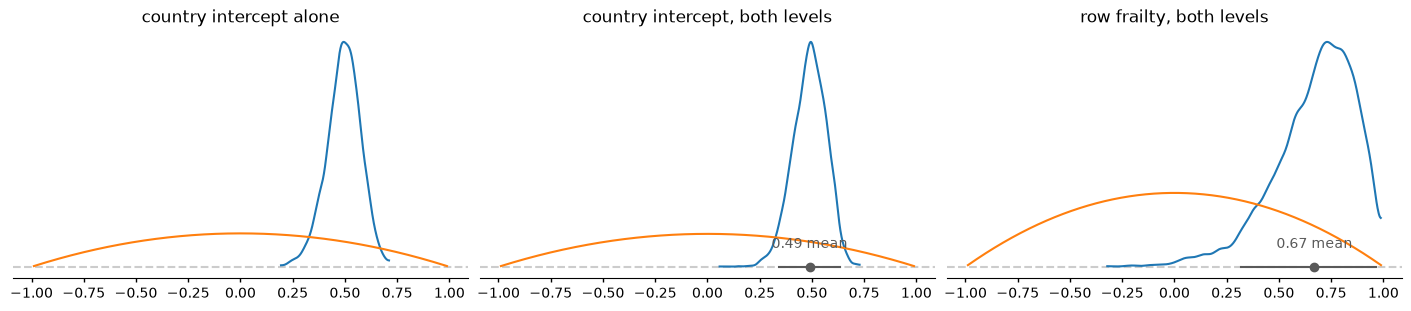

In [12]:
both_diagnostics = summarize(both_idata, [*BOTH_PARAMETERS, "country_offset", "frailty_offset"])
both_diagnostics = both_diagnostics[["ess_bulk", "ess_tail", "r_hat"]]
both_divergences = int(both_idata.sample_stats["diverging"].sum())

print(f"{both_divergences} divergences; worst r_hat {both_diagnostics['r_hat'].max():.3f}; "
      f"smallest bulk ESS {both_diagnostics['ess_bulk'].min():.0f} ({both_diagnostics['ess_bulk'].idxmin()})")

correlations = xr.Dataset({"country intercept alone": idata.posterior["country_corr"],
                           "country intercept, both levels": both_idata.posterior["country_corr"],
                           "row frailty, both levels": both_idata.posterior["frailty_corr"]})
plot_posterior_with_prior(correlations,
                          {name: pz.BetaScaled(alpha=2, beta=2, lower=-1, upper=1) for name in correlations},
                          n_cols=3)
plt.show()

The country-level correlation is 0.49 with an 89% interval from 0.36 to 0.61 in both models, so the row frailty took nothing from it. The row-level correlation is 0.67 with an interval from 0.33 to 0.92, on frailty scales of 0.20 and 0.28 on the log scale. What is left in a row after the country intercepts is a fifth to a quarter of a log unit, and it still moves both classes together, though a correlation on a residual that small is a weaker thing to estimate.

In the comparison below this model is 20 ahead of the correlated intercepts with a standard error of 3.5, at 832 effective parameters against 278 and with 53 rows where the importance weights fail. That is what a per-row latent does to leave-one-out, and the 20 is read with it.

## Against notebooks 01 and 02

Leave-one-out expected log predictive density for the count. The both-levels model has a frailty per row, and leaving an observation out removes the only data its frailty has, so its importance weights are the case PSIS handles worst. The Pareto k count says how many rows that affects.

In [13]:
fits = {"01 zinb glm": az.from_netcdf(FIT_DIR / "zinb_glm.nc"),
        "02 country intercept": az.from_netcdf(FIT_DIR / "country_intercept.nc"),
        "06 correlated country intercept": idata,
        "06 both levels": both_idata}
loos = {name: az.loo(fit, var_name="y") for name, fit in fits.items()}

print("rows with Pareto k above 0.7:", {name: int((loo.pareto_k > 0.7).sum()) for name, loo in loos.items()})
comparison = az.compare(loos, round_to=1)
comparison[["rank", "elpd", "se", "elpd_diff", "dse", "p"]]

/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust mo

rows with Pareto k above 0.7: {'01 zinb glm': 0, '02 country intercept': 0, '06 correlated country intercept': 1, '06 both levels': 53}


,rank,elpd,se,elpd_diff,dse,p
06 both levels,0,-11641.80,117.10,0.00,0.00,831.70
06 correlated country intercept,1,-11662.20,117.20,-20.40,3.50,277.60
02 country intercept,2,-11664.60,117.10,-22.80,4.80,284.80
01 zinb glm,3,-12912.90,129.70,-1271.10,48.50,16.80


## What was learned

A country's two intercepts are correlated at 0.49, with an 89% interval from 0.36 to 0.61, against a prior centered on zero. Half of a country's departure from its covariates is shared by its two classes across 43 years. A hazard year does not last four decades, so that share is reporting effort or a persistent trait of the country, and it is the first piece of joint structure this series has found. Everything else in the model is notebook 02 to the second digit: the scales are 0.77 and 0.75 against `tau` at 0.75 and 0.75, the dispersions 8.8 and 11.3 against 8.9 and 11.3, the slopes and their ESS unchanged. LOO puts the two models 2.4 apart with a standard error of 3.3.

The correlation costs nothing in fit and adds nothing to it. Its value is in prediction. A country with one class recorded gets a prediction for the other, and a country outside the panel gets its two intercepts drawn together. It is one parameter, it mixes, and the model has no per-row latent, so its checks and its LOO mean what they say.

There is also co-movement within a country-year. With a correlated frailty at both levels the country-level correlation stays at 0.49 and the row level shows 0.67, from 0.33 to 0.92, on a residual of a fifth to a quarter of a log unit. It is real, weakly identified, and expensive: a latent per observation, an LOO that PSIS cannot compute, and predictive checks that reproduce the data. It is not carried forward. If the damage side turns out to need a per-event hazard signal shared across classes, this is where it lives.

Two things follow. The joint series continues from the correlated-intercept model, which is notebook 02 plus one parameter. And a model whose latent has one observation behind it cannot be checked by its posterior predictive, because that predictive reproduces the observation for any parameter values. The check for such a model draws the latent afresh from its fitted population distribution, and coverage measured that way reports calibration, which says nothing about accuracy.